# ****Описание проекта****

Вы — маркетинговый аналитик развлекательного приложения Procrastinate Pro+. Несмотря на огромные вложения в рекламу, последние несколько месяцев компания терпит убытки.  
Ваша задача — разобраться в причинах и помочь компании выйти в плюс.  

Есть данные о пользователях, привлечённых с 1 мая по 27 октября 2019 года:  
* лог сервера с данными об их посещениях,
* выгрузка их покупок за этот период,
* рекламные расходы.

Вам предстоит изучить:  
* откуда приходят пользователи и какими устройствами они пользуются,
* сколько стоит привлечение пользователей из различных рекламных каналов,
* сколько денег приносит каждый клиент,
* когда расходы на привлечение клиента окупаются,
* какие факторы мешают привлечению клиентов.

# Описание данных

В вашем распоряжении три датасета.   
Файл visits_info_short.csv хранит лог сервера с информацией о посещениях сайта, orders_info_short.csv — информацию о заказах, а costs_info_short.csv — информацию о расходах на рекламу.

Структура visits_info_short.csv:
* `User Id` — уникальный идентификатор пользователя,
* `Region` — страна пользователя,
* `Device` — тип устройства пользователя,
* `Channel` — идентификатор источника перехода,
* `Session Start` — дата и время начала сессии,
* `Session End` — дата и время окончания сессии.  

Структура orders_info_short.csv:  
* `User Id` — уникальный идентификатор пользователя,
* `Event Dt` — дата и время покупки,
* `Revenue` — сумма заказа.  

Структура costs_info_short.csv:  
* `dt` — дата проведения рекламной кампании,
* `Channel` — идентификатор рекламного источника,
* `costs` — расходы на эту кампанию.

### Загрузите данные и подготовьте их к анализу

Загрузите данные о визитах, заказах и рекламных расходах из CSV-файлов в переменные.  
Изучите данные и выполните предобработку. Есть ли в данных пропуски и дубликаты? Убедитесь, что типы данных во всех колонках соответствуют сохранённым в них значениям. Обратите внимание на столбцы с датой и временем.

#### Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime, timedelta

#### Сохраняем данные в переменные

In [2]:
try:
    visits = pd.read_csv('/datasets/visits_info_short.csv')
    orders = pd.read_csv('/datasets/orders_info_short.csv')
    costs = pd.read_csv('/datasets/costs_info_short.csv')
    print(f"Успешно загружены файлы")
except:
    print(f"Ошибка при загрузке файлов")

Успешно загружены файлы


#### Общая информация о датафреймах

In [3]:
display(visits.head())
display(orders.head())
display(costs.head())

,User Id,Region,Device,Channel,Session Start,Session End
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40


,User Id,Event Dt,Revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99


,dt,Channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1


Нужно привести названия столбцов к змеиному регистру. 

In [4]:
visits.columns = visits.columns.str.lower().str.replace(' ', '_')
orders.columns = orders.columns.str.lower().str.replace(' ', '_')
costs.columns = costs.columns.str.lower().str.replace(' ', '_')

In [5]:
display(visits.info())
display(orders.info())
display(costs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        309901 non-null  int64 
 1   region         309901 non-null  object
 2   device         309901 non-null  object
 3   channel        309901 non-null  object
 4   session_start  309901 non-null  object
 5   session_end    309901 non-null  object
dtypes: int64(1), object(5)
memory usage: 14.2+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   40212 non-null  int64  
 1   event_dt  40212 non-null  object 
 2   revenue   40212 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 942.6+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


None

In [6]:
display(visits.duplicated().sum())
display(orders.duplicated().sum())
display(costs.duplicated().sum())

0

0

0

In [7]:
visits[['session_start', 'session_end']] = visits[['session_start', 'session_end']].apply(lambda x: pd.to_datetime(x))
orders['event_dt'] = orders['event_dt'].apply(lambda x: pd.to_datetime(x))
costs['dt'] = costs['dt'].apply(lambda x: pd.to_datetime(x))

In [8]:
display(visits.head())
display(orders.head())
display(costs.head())

,user_id,region,device,channel,session_start,session_end
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40


,user_id,event_dt,revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99


,dt,channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1


In [9]:
display(visits.info())
display(orders.info())
display(costs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        309901 non-null  int64         
 1   region         309901 non-null  object        
 2   device         309901 non-null  object        
 3   channel        309901 non-null  object        
 4   session_start  309901 non-null  datetime64[ns]
 5   session_end    309901 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 14.2+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   40212 non-null  int64         
 1   event_dt  40212 non-null  datetime64[ns]
 2   revenue   40212 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 942.6 KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   dt       1800 non-null   datetime64[ns]
 1   channel  1800 non-null   object        
 2   costs    1800 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 42.3+ KB


None

**Вывод:**  
* Импортировал библиотеки и записал данные в датафреймы;
* Дубликатов и пропусков нет;
* Заменил тип данных у столбцов с датами;
* Названия столбцов были приведены к змеиному регистру.

### Задайте функции для расчёта и анализа LTV, ROI, удержания и конверсии.

Разрешается использовать функции, с которыми вы познакомились в теоретических уроках.

Это функции для вычисления значений метрик:

- `get_profiles()` — для создания профилей пользователей,
- `get_retention()` — для подсчёта Retention Rate,
- `get_conversion()` — для подсчёта конверсии,
- `get_ltv()` — для подсчёта LTV.

А также функции для построения графиков:

- `filter_data()` — для сглаживания данных,
- `plot_retention()` — для построения графика Retention Rate,
- `plot_conversion()` — для построения графика конверсии,
- `plot_ltv_roi` — для визуализации LTV и ROI.

#### Функция для создания пользовательских профилей

In [10]:
def get_profiles(sessions, orders, ad_costs, event_names=[]):
    '''
    Функция get_profiles предназначена для создания профилей пользователей на основе данных о сессиях, 
    заказах и затратах на рекламу. Она агрегирует информацию о первой сессии каждого пользователя, 
    определяет, является ли пользователь покупателем, 
    рассчитывает стоимость привлечения нового пользователя и объединяет эти данные.
    '''

    profiles = (
        sessions.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()
    )

    profiles['dt'] = profiles['first_ts'].dt.date
    profiles['dt'] = pd.to_datetime(profiles['dt'], format = '%Y-%m-%d')
    profiles['month'] = profiles['first_ts'].astype('datetime64[M]')
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )

    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles

#### Функция для расчёта удержания

In [11]:
def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    '''
    Функция get_retention предназначена для расчета и анализа показателей удержания (retention) пользователей. 
    Она позволяет оценить, сколько пользователей, 
    привлеченных в определенный период (когорта), 
    продолжают оставаться активными (совершать сессии) в последующие дни. 
    Функция возвращает сырые данные, сгруппированные когорты и когорты, разбитые по временным периодам.
    '''

    dimensions = ['payer'] + dimensions

    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return result_raw, result_grouped, result_in_time 

#### Функция для расчёта конверсии

In [12]:
def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    '''
    Функция get_conversion предназначена для расчета и анализа конверсии пользователей в покупку. 
    Она оценивает, какой процент пользователей, привлеченных в определенный период (когорту), 
    совершает свою первую покупку в течение заданного временного горизонта. 
    Функция возвращает сырые данные, агрегированную таблицу конверсии по когортам и временным периодам.
    '''

    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users' 
        dimensions = dimensions + ['cohort']

    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        result = result.fillna(0).cumsum(axis = 1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    if 'cohort' in dimensions: 
        dimensions = []

    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return result_raw, result_grouped, result_in_time

#### Функция для расчёта LTV и ROI

In [13]:
def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    '''
    Функция get_ltv предназначена для расчета и анализа пожизненной ценности (Lifetime Value - LTV) пользователей. 
    Она оценивает суммарный доход, полученный от пользователей, 
    когортированных по дате привлечения и другим измерениям, в течение заданного временного горизонта, 
    а также рассчитывает окупаемость инвестиций (ROI).
    '''

    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        result = result.fillna(0).cumsum(axis=1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes

        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )
        roi = result.div(cac['cac'], axis=0)
        roi = roi[~roi['cohort_size'].isin([np.inf])]
        roi['cohort_size'] = cohort_sizes
        roi['cac'] = cac['cac']
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]
        return result, roi

    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    if 'cohort' in dimensions:
        dimensions = []
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )
    return (
        result_raw,  
        result_grouped,  
        result_in_time, 
        roi_grouped, 
        roi_in_time,  
    ) 

#### Функции для визуализации

In [14]:
def filter_data(df, window):
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df 

In [15]:
def plot_retention(retention, retention_history, horizon, window=7):

    plt.figure(figsize=(15, 10))
    retention = retention.drop(columns=['cohort_size', 0])
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    ax3 = plt.subplot(2, 2, 3)
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания неплатящих пользователей на {}-й день'.format(
            horizon
        )
    )
    plt.tight_layout()
    plt.show() 

In [16]:
def plot_conversion(conversion, conversion_history, horizon, window=7):

    plt.figure(figsize=(15, 5))
    conversion = conversion.drop(columns=['cohort_size'])
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 

In [17]:
def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    plt.figure(figsize=(20, 10))
    ltv = ltv.drop(columns=['cohort_size'])
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    cac_history = roi_history[['cac']]
    roi = roi.drop(columns=['cohort_size', 'cac'])
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')

    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 

**Вывод:**  
Были написаны основные функции:
* для создания профилей пользователей;
* для подсчёта Retention Rate;
* для подсчёта конверсии;
* для подсчёта LTV.

а также функции для построения графиков:
* для сглаживания данных;
* для построения графика Retention Rate;
* для построения графика конверсии;
* для визуализации LTV и ROI.

### Исследовательский анализ данных

- Составьте профили пользователей. Определите минимальную и максимальную даты привлечения пользователей.
- Выясните, из каких стран пользователи приходят в приложение и на какую страну приходится больше всего платящих пользователей. Постройте таблицу, отражающую количество пользователей и долю платящих из каждой страны.
- Узнайте, какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи. Постройте таблицу, отражающую количество пользователей и долю платящих для каждого устройства.
- Изучите рекламные источники привлечения и определите каналы, из которых пришло больше всего платящих пользователей. Постройте таблицу, отражающую количество пользователей и долю платящих для каждого канала привлечения.

После каждого пункта сформулируйте выводы.

#### Профили пользователей.

In [18]:
profiles = get_profiles(visits, orders, costs)
display(profiles.head())

,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237
2,6085896,2019-10-01 09:58:33,organic,iPhone,France,2019-10-01,2019-10-01,False,0.000000
3,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,2019-08-01,False,0.988235
4,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,2019-10-01,False,0.230769


In [19]:
display(f'Начальная дата')
display(profiles['first_ts'].min())
display(f'Последняя дата')
display(profiles['first_ts'].max())

'Начальная дата'

Timestamp('2019-05-01 00:00:41')

'Последняя дата'

Timestamp('2019-10-27 23:59:04')

*Промежуточный вывод:*  
Начальная дата привлечения 1 мая, последняя дата привлечения 27 октября, совпадает с указанным в описании.

#### Платящие пользователи по странам.

In [20]:
region_buy_alt1 = (
    profiles.groupby('region')
    .agg(
        unique_users=('user_id', 'nunique'), 
        total_payers=('payer', 'sum')        
    )
    .assign(
        payer_per=lambda x: (x['total_payers'] / x['unique_users']) * 100 
    )
    .sort_values(by='payer_per', ascending=False)
    .drop(columns=['total_payers'])
)
display(region_buy_alt1)

,unique_users,payer_per
region,,
United States,100002,6.901862
Germany,14981,4.111875
UK,17575,3.982930
France,17450,3.799427


*Промежуточный вывод:*  
* По пользователям на первом месте США со 100 тыс. из них 6,9% платящих;
* По пользователям на втором месте Великобритания с 17,6 тыс. из них 3,9% платящих;
* По пользователям на третьем месте Франция с 17,5 тыс. из них 3,8% платящих;
* По пользователям на последнем месте Германия с 14,9 тыс. из них 4,1% платящих.

#### Платящие пользователи по устройствам.

In [21]:
device_buy_alt1 = (
    profiles.groupby('device')
    .agg(
        unique_users=('user_id', 'nunique'), 
        total_payers=('payer', 'sum')        
    )
    .assign(
        payer_per=lambda x: (x['total_payers'] / x['unique_users']) * 100 
    )
    .sort_values(by='unique_users', ascending=False)
    .drop(columns=['total_payers'])
)
display(device_buy_alt1)

,unique_users,payer_per
device,,
iPhone,54479,6.207897
Android,35032,5.851793
PC,30455,5.046790
Mac,30042,6.364423


*Промежуточный вывод:*  
* По пользователям на первом месте iPhone с 54,4 тыс. из них 6,2% платящих;
* По пользователям на втором месте Android с 35 тыс. из них 5,8% платящих;
* По пользователям на третьем месте PC с 30,5 тыс. из них 5% платящих;
* По пользователям на последнем месте Mac с 30 тыс. из них 6,4% платящих.

#### Доля платящих для каждого канала привлечения

In [22]:
channel_buy_alt1 = (
    profiles.groupby('channel')
    .agg(
        unique_users=('user_id', 'nunique'), 
        total_payers=('payer', 'sum')       
    )
    .assign(
        payer_per=lambda df: (df['total_payers'] / df['unique_users']) * 100 
    )
    .sort_values(by='total_payers', ascending=False) 
)
display(channel_buy_alt1)

,unique_users,total_payers,payer_per
channel,,,
FaceBoom,29144,3557,12.204914
TipTop,19561,1878,9.600736
organic,56439,1160,2.055316
WahooNetBanner,8553,453,5.296387
AdNonSense,3880,440,11.340206
RocketSuperAds,4448,352,7.913669
LeapBob,8553,262,3.063253
OppleCreativeMedia,8605,233,2.707728
lambdaMediaAds,2149,225,10.469986


*Промежуточный вывод:*  
* По платящим пользователям на первом месте FaceBoom с 3557 чел.;
* По платящим пользователям на втором месте TipTop с 1878 чел.;
* По платящим пользователям на третьем месте organic с 1160 чел.;
* По платящим пользователям на последнем месте MediaTornado с 156 чел.

**Вывод:**  
1. География: США — доминирующий рынок, как по абсолютному числу пользователей (100 тыс.), так и по проценту платящих (6.9%), значительно опережая Великобританию, Францию и Германию.
2. Устройства: iPhone лидирует по количеству пользователей (54.4 тыс.), а пользователи Mac, хотя и самые малочисленные (30 тыс.), показывают самый высокий процент платящих (6.4%).
3. Каналы привлечения: FaceBoom — привлёк больше всего платящих пользователей (3557 чел.), существенно опережая TipTop, organic и MediaTornado.

### Маркетинг

- Посчитайте общую сумму расходов на маркетинг.
- Выясните, как траты распределены по рекламным источникам, то есть сколько денег потратили на каждый источник.
- Постройте график с визуализацией динамики изменения расходов во времени по неделям по каждому источнику. Затем на другом графике визуализируйте динамику изменения расходов во времени по месяцам по каждому источнику.
- Узнайте, сколько в среднем стоило привлечение одного пользователя (CAC) из каждого источника. Используйте профили пользователей.

Напишите промежуточные выводы.

#### Расходы на маркетинг

In [23]:
display(costs['costs'].sum())

105497.30000000002

*Промежуточный вывод:*  
Общие расходы на маркетинг составляют 105497.

#### Распределение расходов по каналам

In [24]:
costs_by_channel_alt1 = (
    costs.groupby('channel')
    .agg(total_costs=('costs', 'sum')) 
    .sort_values(by='total_costs', ascending=False)
)

total_overall_costs = costs_by_channel_alt1['total_costs'].sum()

costs_by_channel_alt1['percentage_of_total'] = (
    costs_by_channel_alt1['total_costs'] / total_overall_costs
) * 100

costs_by_channel_alt1['percentage_of_total'] = costs_by_channel_alt1['percentage_of_total'].round(2).astype(str) + '%'

display(costs_by_channel_alt1)

,total_costs,percentage_of_total
channel,,
TipTop,54751.30,51.9%
FaceBoom,32445.60,30.75%
WahooNetBanner,5151.00,4.88%
AdNonSense,3911.25,3.71%
OppleCreativeMedia,2151.25,2.04%
RocketSuperAds,1833.00,1.74%
LeapBob,1797.60,1.7%
lambdaMediaAds,1557.60,1.48%
MediaTornado,954.48,0.9%


*Промежуточный вывод:*  
* По затратам на канал на первом месте TipTop с 54751.30, что составляет 51.9% от общих затрат;
* По затратам на канал на втором месте FaceBoom с 32445.60, что составляет 30.75% от общих затрат;
* По затратам на канал на третьем месте WahooNetBanner с 5151.00, что составляет 4.88% от общих затрат;
* По затратам на канал на последнем месте YRabbit с 944.22, что составляет 0.9% от общих затрат.

#### Динамика изменения затрат по каналам

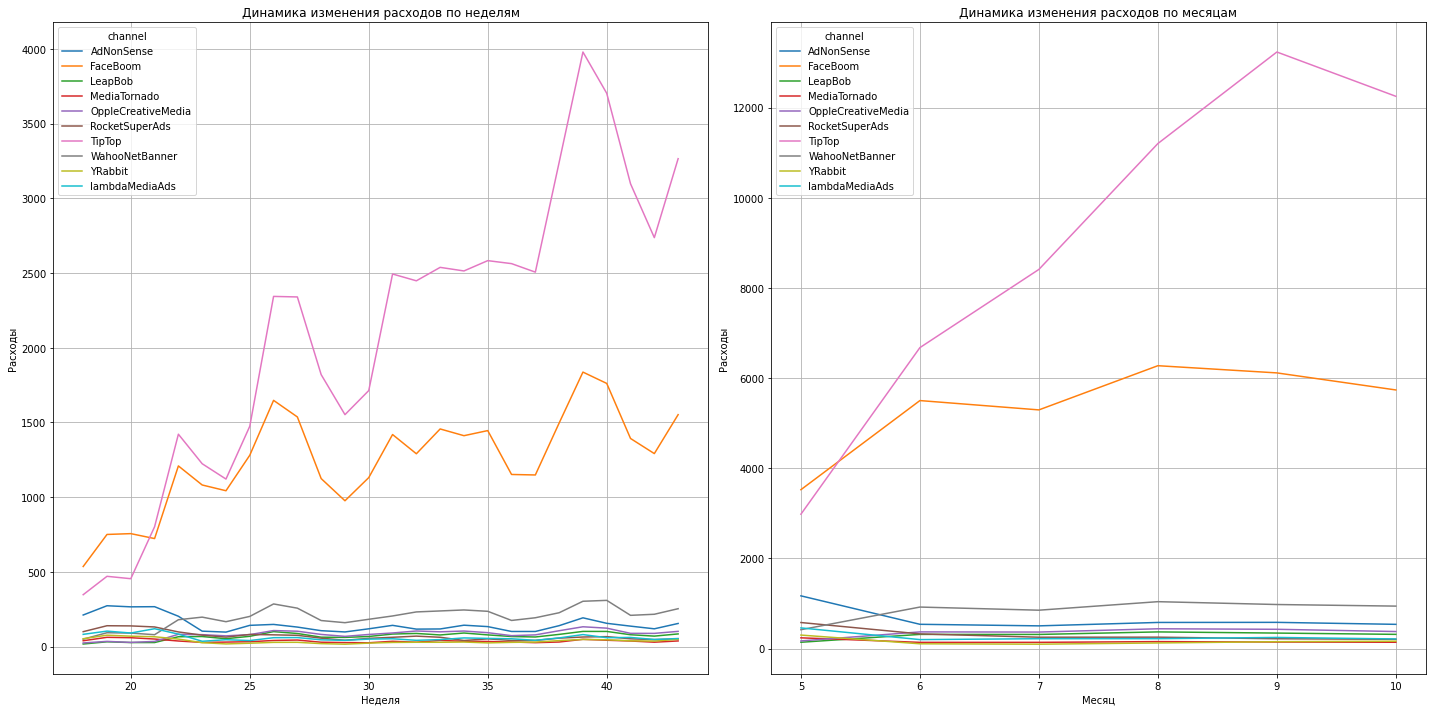

In [25]:
costs['week'] = costs['dt'].dt.isocalendar().week
costs['month'] = costs['dt'].dt.month


fig, axes = plt.subplots(1, 2, figsize=(20, 10))

weekly_costs_data = costs.groupby(['week', 'channel'])['costs'].sum().unstack(level='channel')
weekly_costs_data.plot(grid=True, ax=axes[0])
axes[0].set_title('Динамика изменения расходов по неделям')
axes[0].set_xlabel('Неделя')
axes[0].set_ylabel('Расходы')


monthly_costs_data = costs.groupby(['month', 'channel'])['costs'].sum().unstack(level='channel')
monthly_costs_data.plot(grid=True, ax=axes[1])
axes[1].set_title('Динамика изменения расходов по месяцам')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Расходы')

plt.tight_layout()
plt.show()

*Промежуточный вывод:*  
* Судя по графикам затраты в основном растут только для каналов TipTop, FaceBoom. По остальным минимальные изменения.

#### Средняя стоимость привлечения одного пользователя (CAC)

In [26]:
profiles = profiles.query('channel != "organic"')
result = (
    profiles.groupby('channel')['acquisition_cost'] 
    .mean()                                     
    .sort_values(ascending=False)                  
)

display(result)
display('--------------------------------')
display(f'Средний САС для всего проекта')
display(profiles['acquisition_cost'].mean())

channel
TipTop                2.799003
FaceBoom              1.113286
AdNonSense            1.008054
lambdaMediaAds        0.724802
WahooNetBanner        0.602245
RocketSuperAds        0.412095
OppleCreativeMedia    0.250000
YRabbit               0.218975
MediaTornado          0.218717
LeapBob               0.210172
Name: acquisition_cost, dtype: float64

'--------------------------------'

'Средний САС для всего проекта'

1.1274813239427588

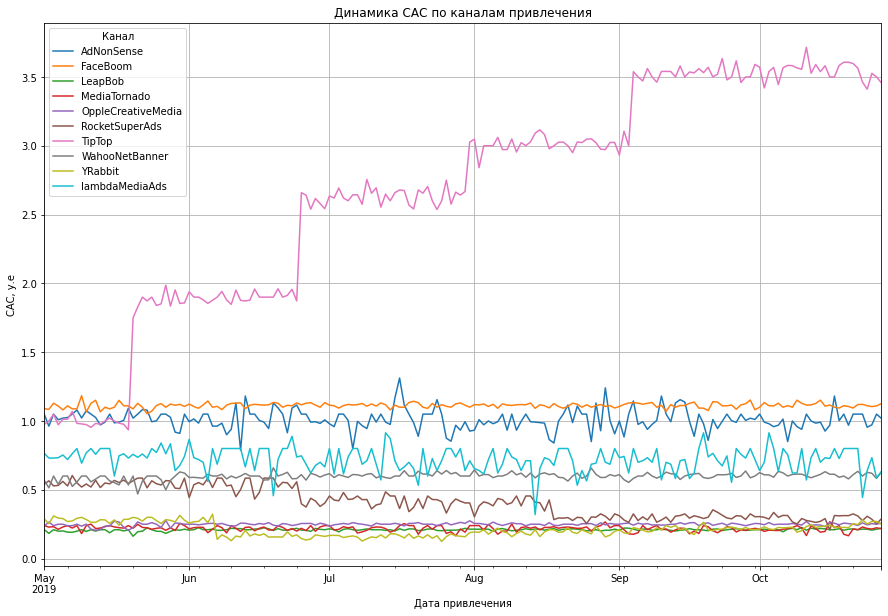

In [27]:
plt.figure(figsize=(15, 10))

cac_dynamics_data = profiles.groupby(['dt', 'channel'])['acquisition_cost'].mean().unstack(level='channel')
cac_dynamics_data.plot(grid=True, ax=plt.gca()) 

plt.ylabel('CAC, у.е')
plt.xlabel('Дата привлечения')
plt.title('Динамика САС по каналам привлечения')
plt.legend(title='Канал') 
plt.show()

*Промежуточный вывод:*  
* По средним затратам на пользователя на первом месте TipTop с 2.799003;
* По средним затратам на пользователя на втором месте FaceBoom с 1.113286;
* По средним затратам на пользователя на третьем месте AdNonSense с 1.008054;
* По динамике видно как растёт средняя стоимость привлечения одного пользователя по каналу TipTop с 1 до 3,5;
* По каналу RocketSuperAds наблюдается снижение CAC c 0,5 до 0,25.

**Вывод:**  
1. Каналы TipTop (54 751.30 у.е., 51.9% от общих затрат) и FaceBoom (32 445.60 у.е., 30.75% от общих затрат) являются лидерами по расходам и единственными, демонстрирующими их рост, в то время как другие каналы показывают минимальные изменения.
2. Несмотря на максимальные инвестиции, TipTop имеет самый высокий средний CAC (2.8 у.е.), который продолжает расти (по данным динамики, с 1 до 3.5 у.е.). Это критический сигнал о снижении эффективности канала, требующий немедленной оптимизации или пересмотра стратегии.
3. FaceBoom занимает второе место по расходам и среднему CAC (1.1 у.е.). Важно отслеживать динамику его CAC, чтобы избежать сценария TipTop.
4. Средний САС по проекту составляет 1.127 у.е.
5. Канал RocketSuperAds демонстрирует позитивную тенденцию, снижая CAC с 0.5 до 0.25 у.е., что указывает на возможную растущую эффективность и потенциал для масштабирования.

### Оцените окупаемость рекламы

Используя графики LTV, ROI и CAC, проанализируйте окупаемость рекламы. Считайте, что на календаре 1 ноября 2019 года, а в бизнес-плане заложено, что пользователи должны окупаться не позднее чем через две недели после привлечения. Необходимость включения в анализ органических пользователей определите самостоятельно.

- Проанализируйте окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проверьте конверсию пользователей и динамику её изменения. То же самое сделайте с удержанием пользователей. Постройте и изучите графики конверсии и удержания.
- Проанализируйте окупаемость рекламы с разбивкой по устройствам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проанализируйте окупаемость рекламы с разбивкой по странам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проанализируйте окупаемость рекламы с разбивкой по рекламным каналам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Ответьте на такие вопросы:
    - Окупается ли реклама, направленная на привлечение пользователей в целом?
    - Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы?
    - Чем могут быть вызваны проблемы окупаемости?

Напишите вывод, опишите возможные причины обнаруженных проблем и промежуточные рекомендации для рекламного отдела.

#### Окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI.

In [28]:
observation_date = datetime(2019, 11, 1).date()
horizon_days = 14

In [29]:
profiles = profiles.query('channel != "organic"') # Исключаем organic, потому что стоимость привлечения 0

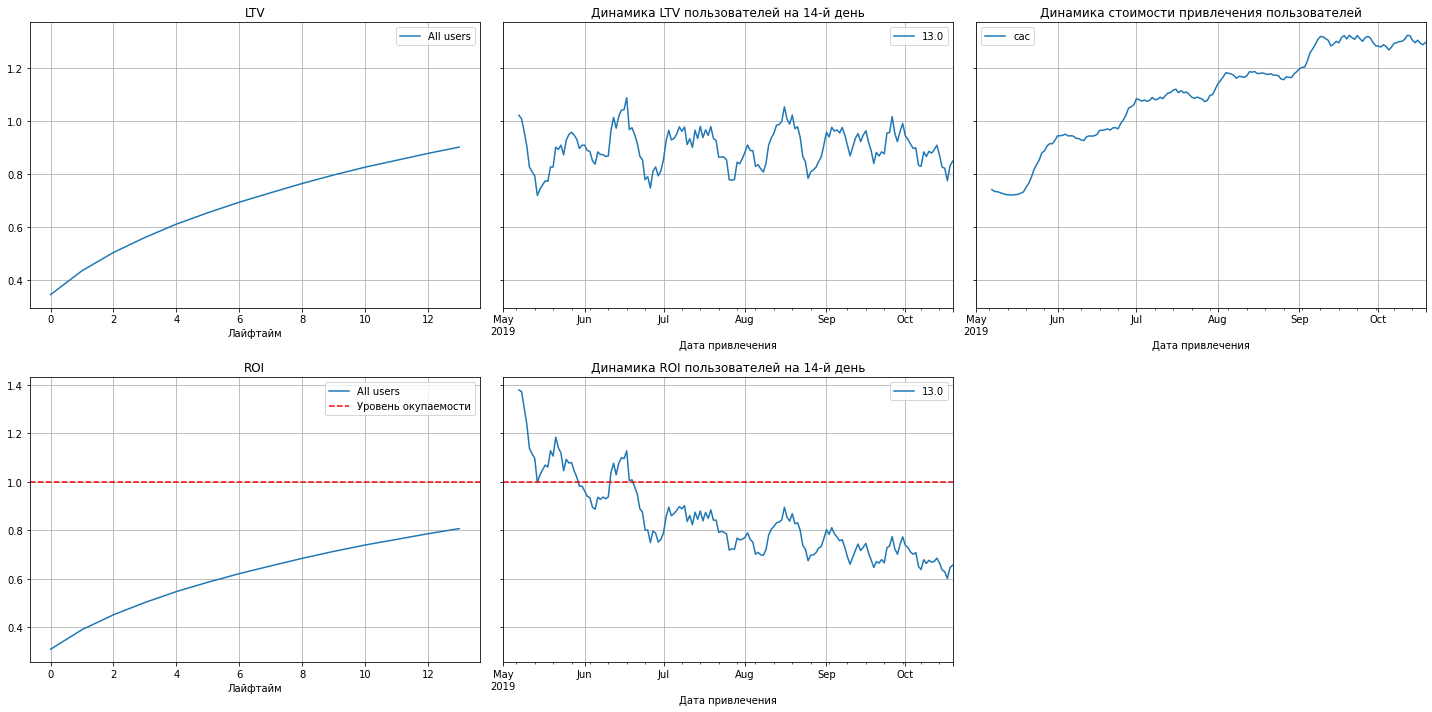

In [30]:
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days
)

plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days)

*Промежуточный вывод:*  
* RIO около 80% показывает, что реклама не окупается; CAC растёт - это может говорить о том, что бюджет растёт. LTV стабилен знеачит нет ухудшения качества пользователей.

#### Динамика конверсии пользователей, динамика удержания пользователей.

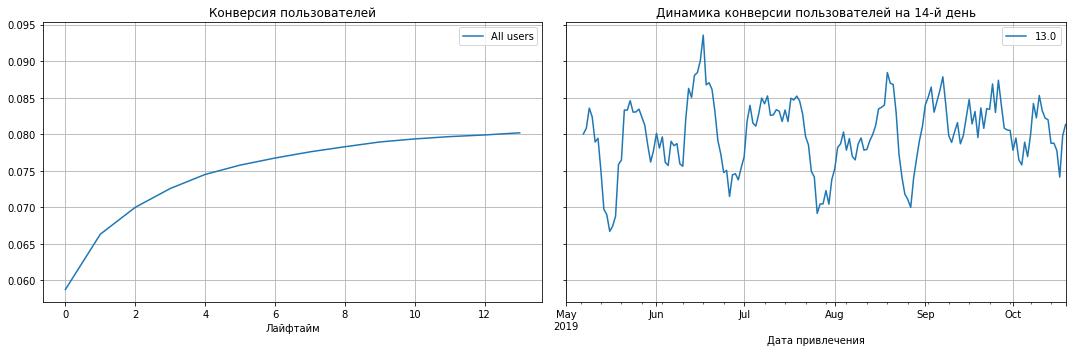

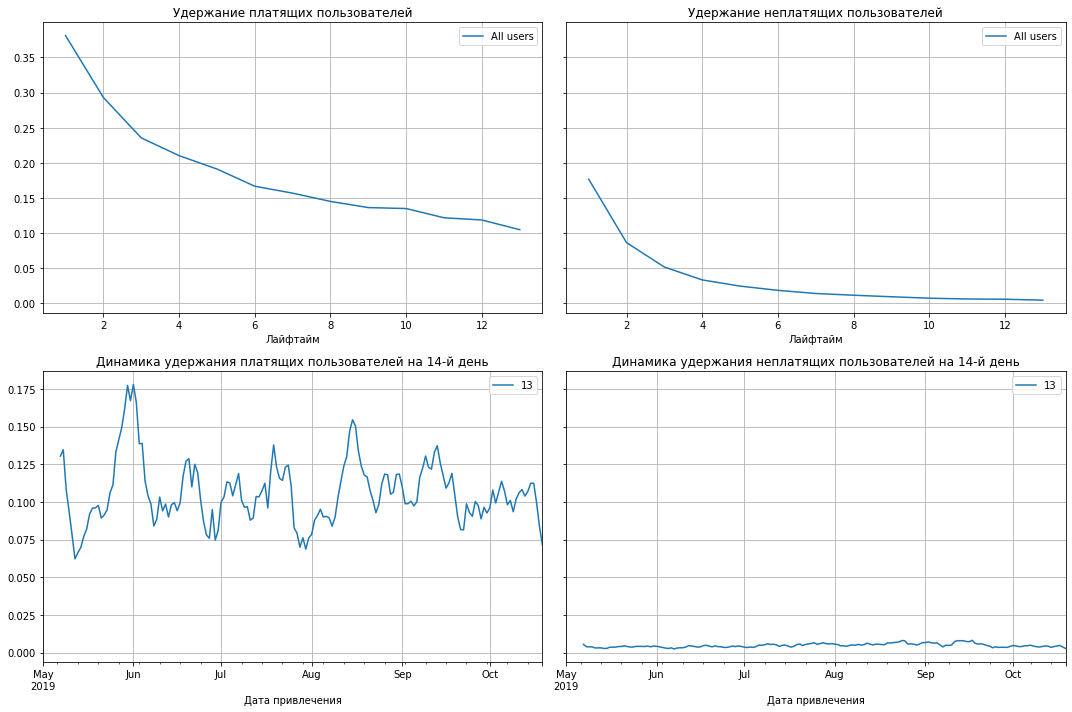

In [31]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days
)

plot_conversion(conversion_grouped, conversion_history, horizon_days) 

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days
)

plot_retention(retention_grouped, retention_history, horizon_days) 

*Промежуточный вывод:*  
* Проблема не в конверсии, она хорошая и постоянная.
* Платящие пользователи лучше удерживаются, чем неплатящие, что не противоречит логике.

#### Окупаемость рекламы по устройствам.

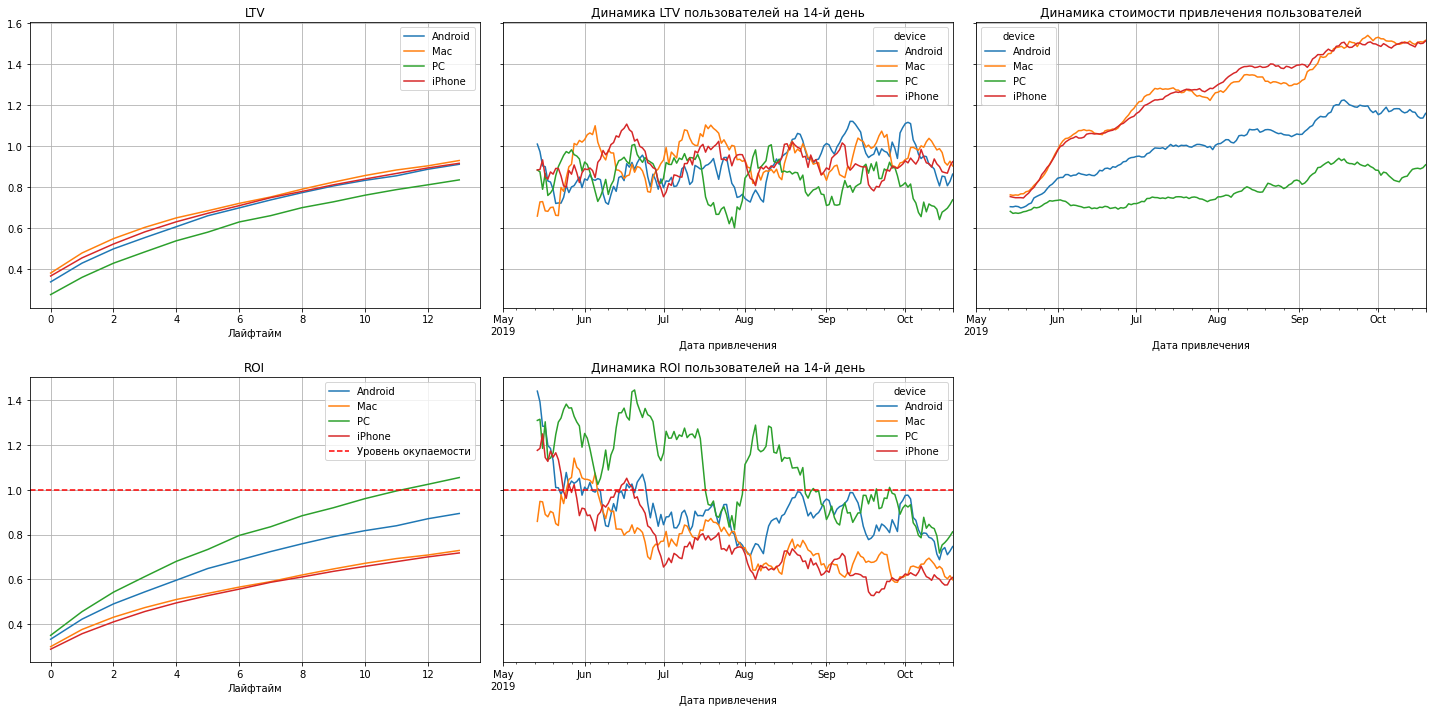

In [32]:
dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

*Промежуточный вывод:*  
* Не окупаются к 14 дню пользователи со всех устройств, кроме тех кто с персональных компьютеров;
* Хуже всего дела обстоят с пользователями iPhone и Mac, учитывая затраты на их привлечение стоит пересмотреть стратегию, скорее всего стоимость их привлечения выше, чем у других устройств.

#### Окупаемость рекламы по старанам.

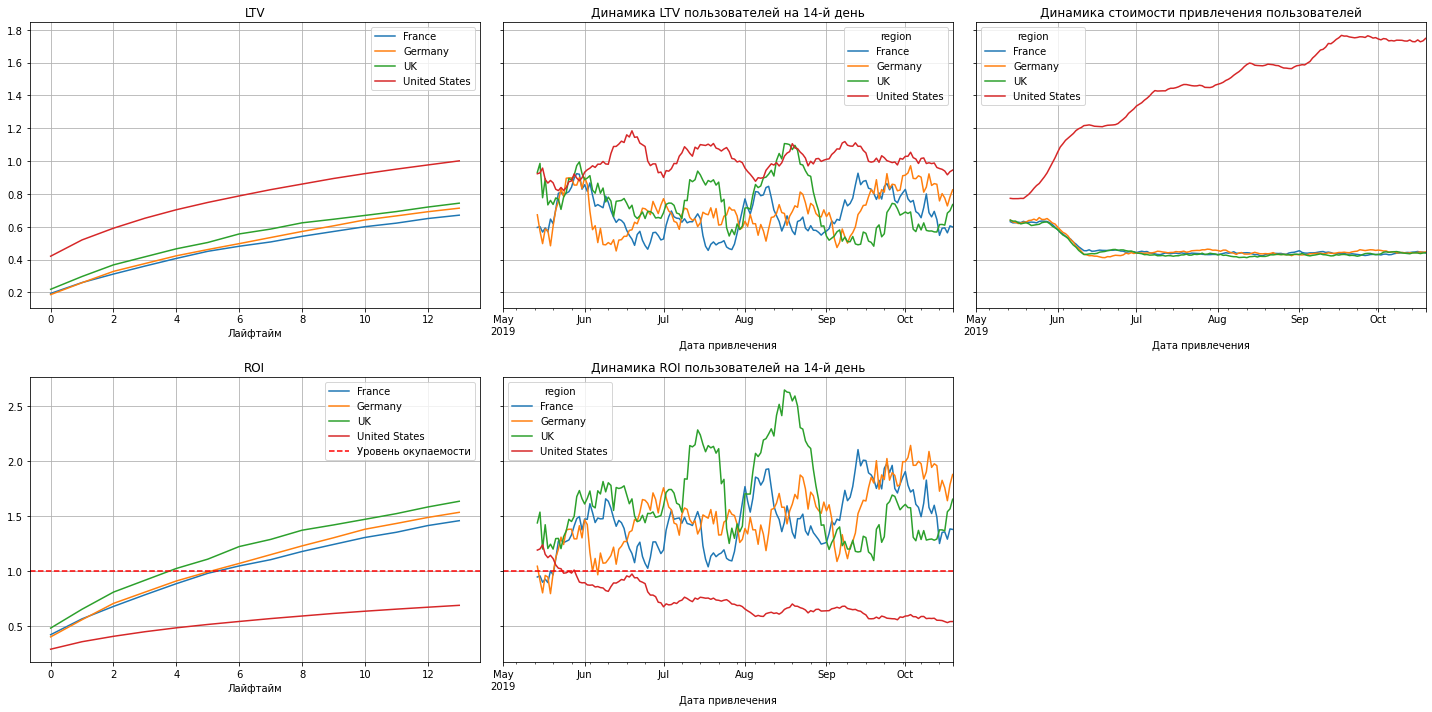

In [33]:
dimensions = ['region']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

*Промежуточный вывод:*  
* Не окупаются к 14 дню пользователи из США, RIO всего 60% к 14 дню;
* Привлечение пользователей из США обходится очень дорого, а если у читывать что их большинство, картина складывается удручающая;
* Стоимость привлечения пользователей из США более чем в 4 раза больше, чем из других стран.

#### Окупаемость рекламы по каналам.

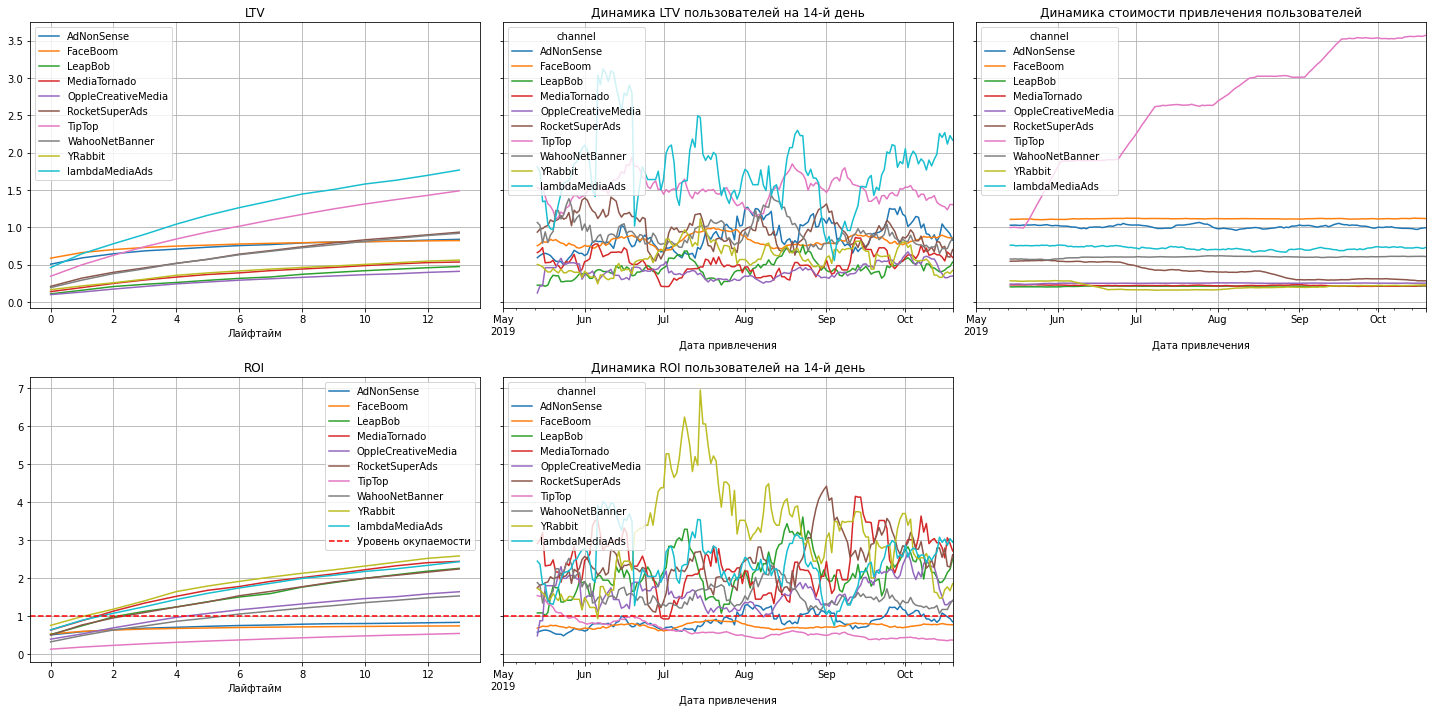

In [34]:
dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

*Промежуточный вывод:*  
* К 14 дню не окупаются пользователи пришедшие из трёх каналов: TipTop, FaceBoom и AdNonSence.

**Посмотрим окупаемость рекламы по каналам для США и Европы по отдельности.**

In [35]:
region = (
    profiles[profiles['payer']==True].pivot_table(index='channel', 
                                              columns = 'region', 
                                              values = 'user_id', 
                                              aggfunc='count')
    .reset_index()
    .sort_values('United States')
    .query('channel != "organic"')
)

In [36]:
usa_ch = region.loc[region['United States'] > 0,'channel']
eu_ch = region.loc[region['UK'] > 0,'channel']

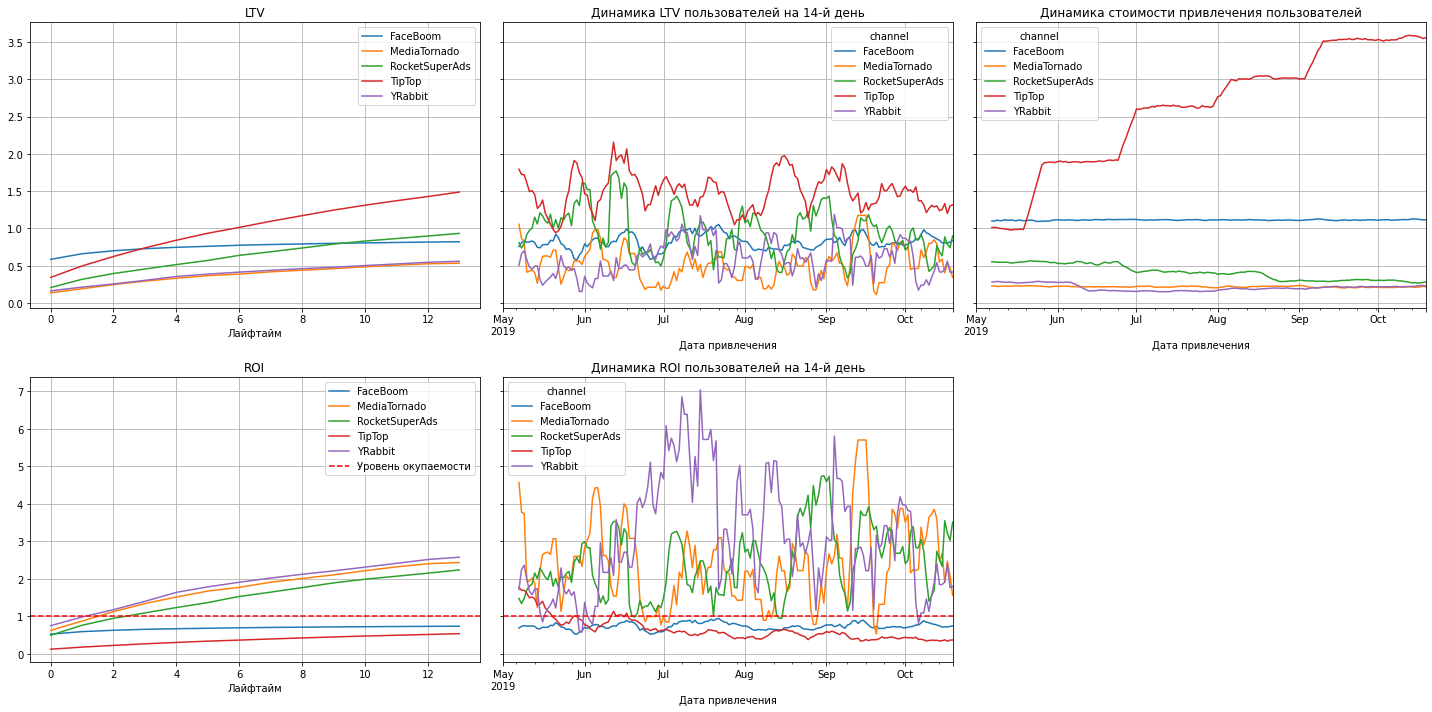

In [37]:
dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel in @usa_ch'), orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=7
)

*Промежуточный вывод:*  
* САС канала TipTop растёт скачками практически каждый месяц, на него затраты растут постоянно. По остальным каналам либо снижение САС либо фиксация на одном уровне.
* LTV стабилен
* По каналам TipTop, FaceBoom не окупается вообще, в тоже время окупаемость по остальным каналам происходит практически сразу на 2 день.

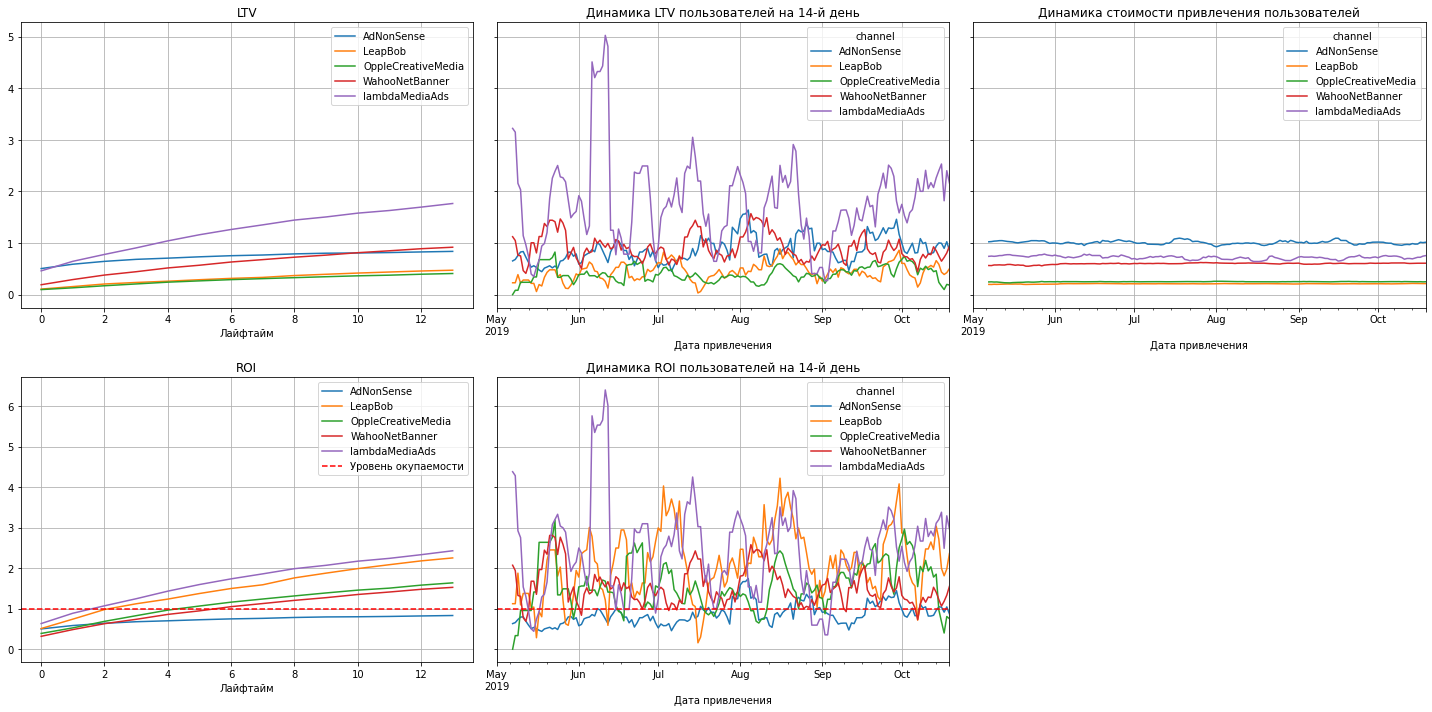

In [38]:
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel in @eu_ch'), orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=7
)

*Промежуточный вывод:*  
* САС стабилен для всех каналов.
* LTV стабилен
* Окупаются все каналы к 5 дню, кроме AdNonSence, он не окупается вообще.

**Конверсия и удержание пользователей**

Оценим конверсию и удержание для каналов TipTop, FaceBoom и AdNonSence.

In [39]:
ch = ['TipTop', 'FaceBoom', 'AdNonSense'] 

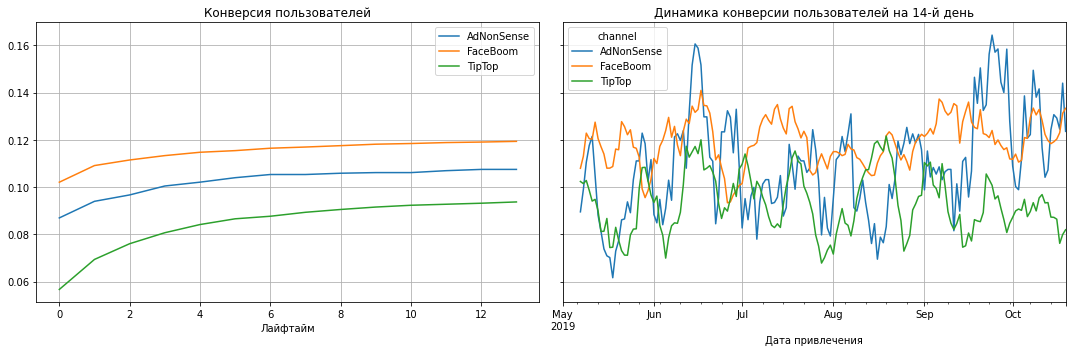

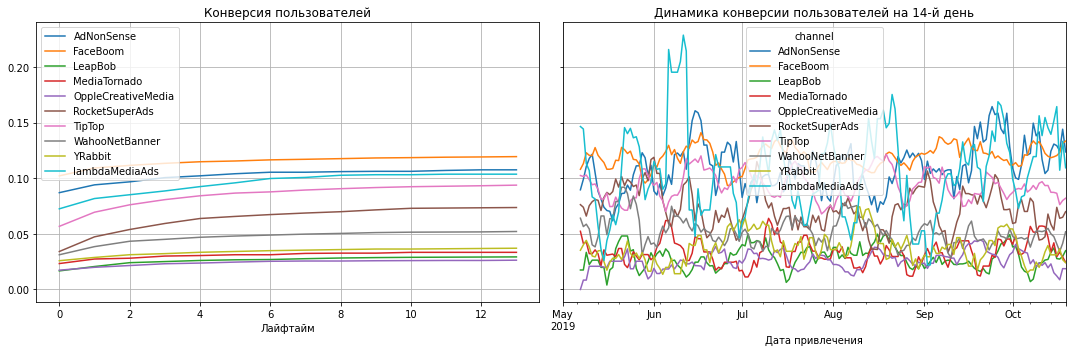

In [40]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles.query('channel in @ch'), orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

*Промежуточный вывод:*  
* Конверсия пользователей из всех сетей происходит достаточно хорошо и стабильно.

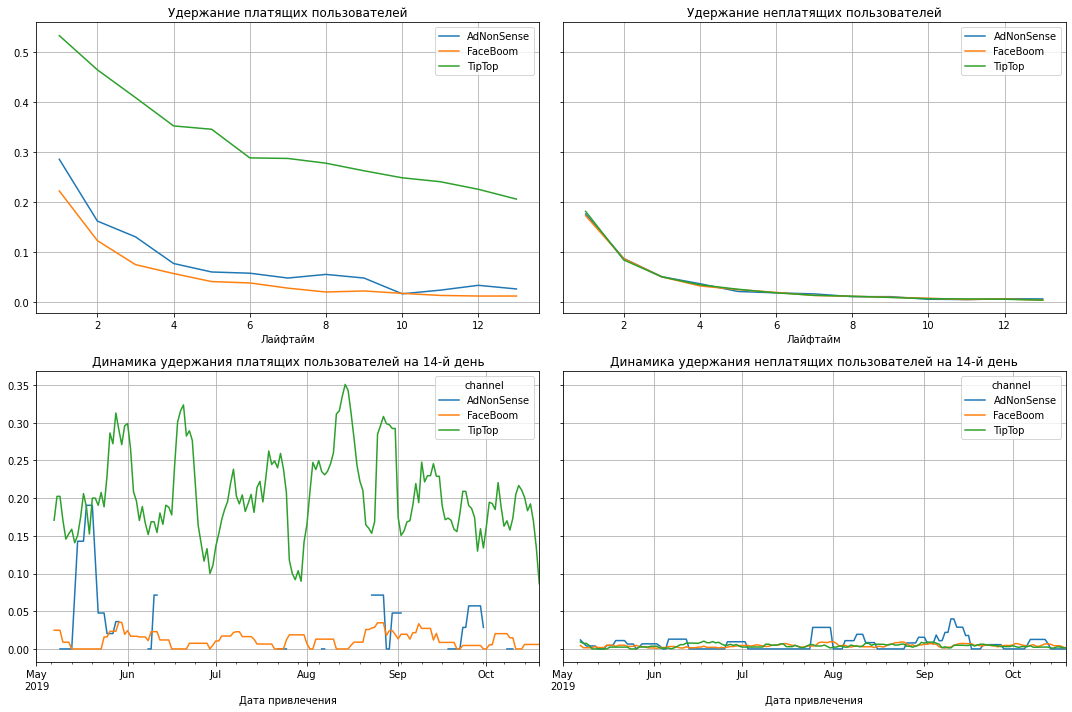

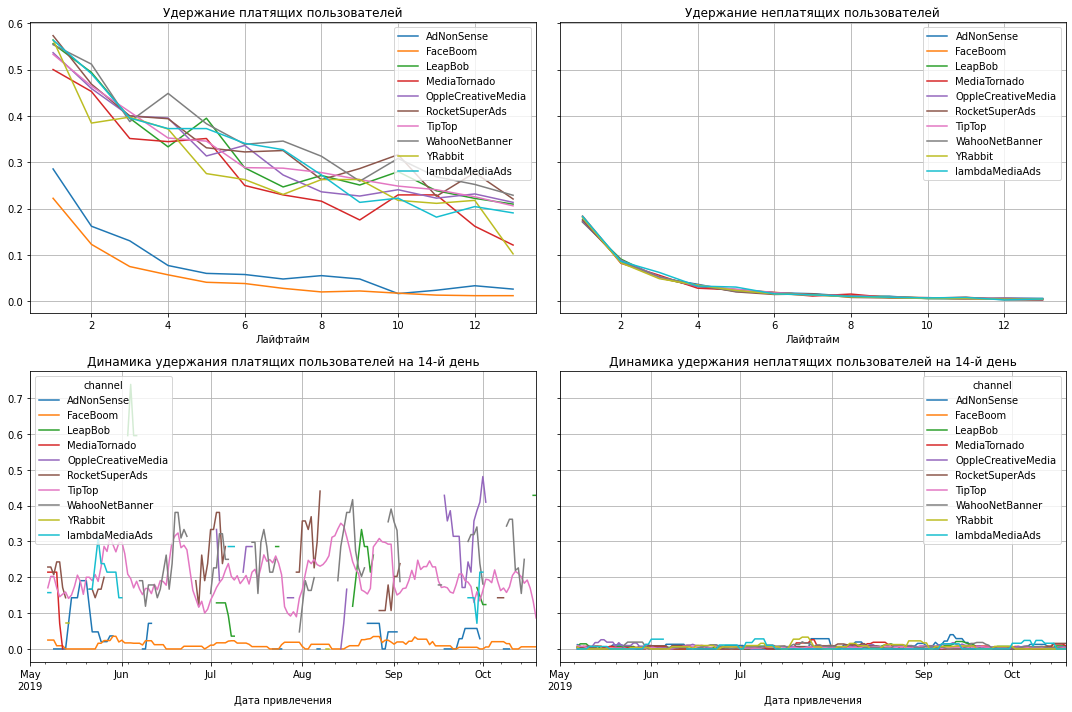

In [41]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles.query('channel in @ch'), visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

*Промежуточный вывод:*  
* Учитывая то, что конверсия пользователей из всех каналов происходит достаточно хорошо и стабильно. Но удержание по каналам FaceBoom и AdNonSence очень низкое, скорее всего с этих каналов приходят пользователи, которым не интересен продукт. А по TipTop можно судить, что канал очень дорогой для рекламы.

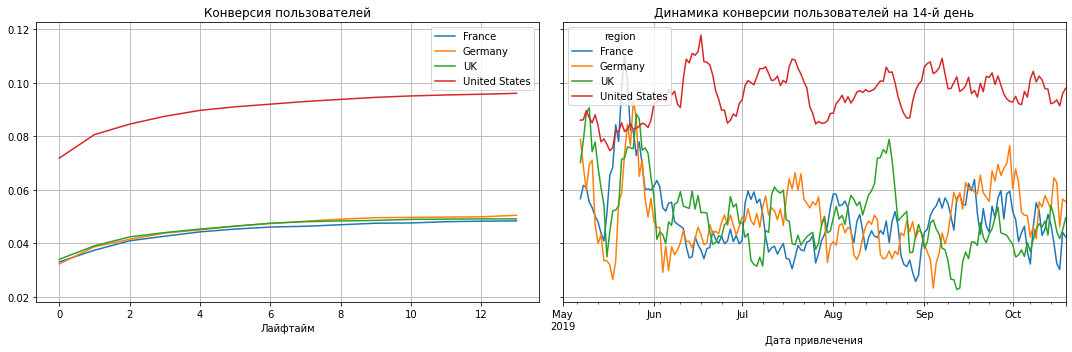

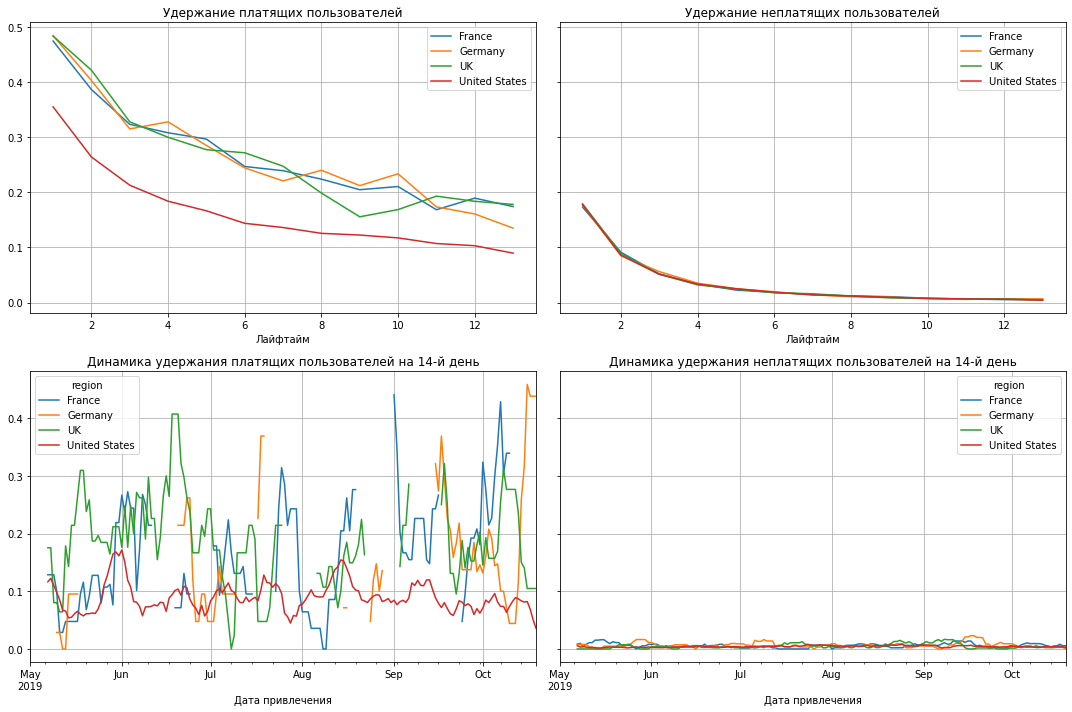

In [42]:
dimensions = ['region']

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

*Промежуточный вывод:*  
* Хоть конверсия высокая для пользователей США по сравнению с Европой, однако удержание платящих пользователей значительно ниже, чем у европейских пользователей. Причина скорее всего в пользователях с канала FaceBoom.

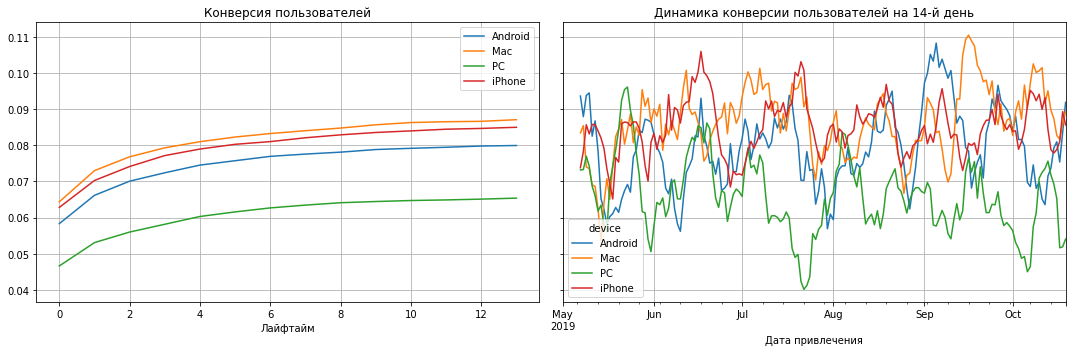

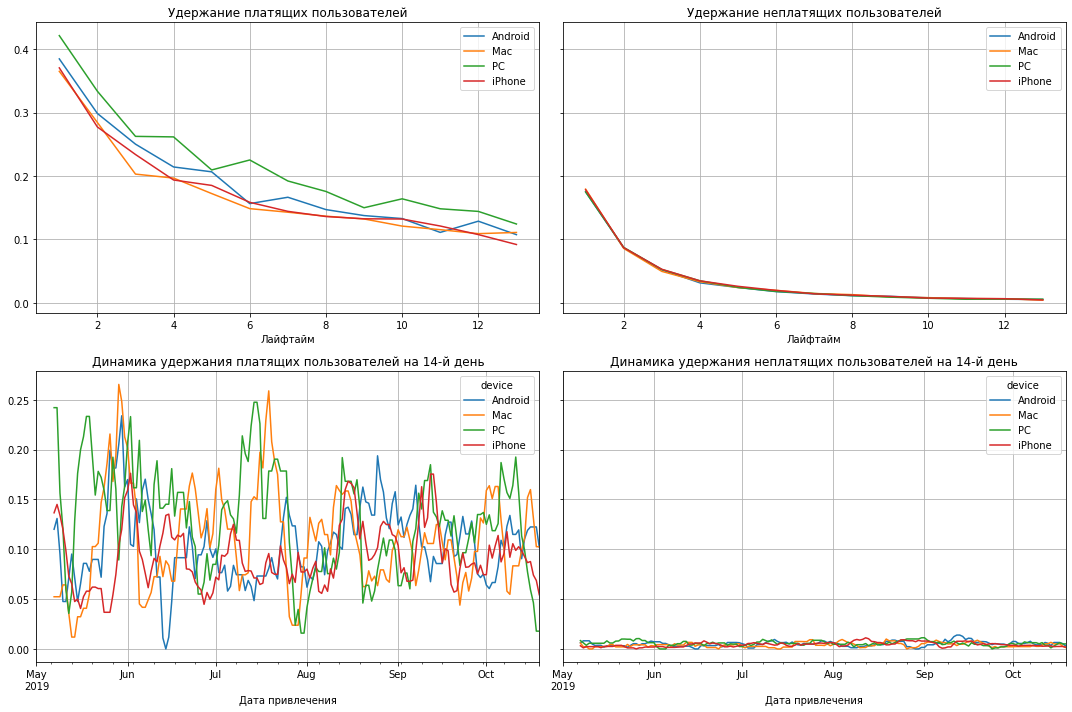

In [43]:
dimensions = ['device']

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days)

*Промежуточный вывод:*  
* Хоть конверсия у пользователей ПК ниже чем у остальных, однако удержание выше.

**Вывод:**  
1. Реклама в целом не окупается. Общий ROI около 80% к 14-му дню показывает, что инвестиции в привлечение пользователей не возвращаются в полном объеме.
2. Пользователи iPhone и Mac (хуже всего), а также все остальные устройства, кроме персональных компьютеров (ПК), не окупаются к 14-му дню. Хоть по пользователям ПК низкая конверсия, однако очень высокое удержание в сравнении.
3. Привлечение пользователей из США обходится более чем в 4 раза дороже, чем у остальных стран. При это окупаемость пользоватлей США на 60%.
4. Рекламные каналы: TipTop, FaceBoom, AdNonSence не окупаются. 
5. Для привлечения пользователей из США и Европы используется по 5 каналов. 
6. Каналы, которые для США окупаются это RocketSuperAds на него можно переключить внимание с TipTop, FaceBoom, которые не окупаются. TipTop слишком дорогой, FaceBoom хоть и с высокой конверсией, однако с низким удержанием скорее всего из-за нецелевой аудитории приходящей с канала. 
7. Каналы, которые для Европы окупаются это lambdaMediaAds на него можно переключить внимание с AdNonSence, который не окупается по той же причине, что и FaceBoom.
8. Также стоит отметить низкое удержание пользователей из США, причина скорее всего в пользователях с канала FaceBoom, которых 31% от общего количества пользователей и их удержание очень плохое.

### Напишите выводы

- Выделите причины неэффективности привлечения пользователей.
- Сформулируйте рекомендации для отдела маркетинга.

*В первой части:*  
* Импортировал библиотеки и записал данные в датафреймы;
* Дубликатов и пропусков нет;
* Заменил тип данных у столбцов с датами;
* Названия столбцов были приведены к змеиному регистру.

*Во второй части:*  
Были написаны основные функции:
* для создания профилей пользователей;
* для подсчёта Retention Rate;
* для подсчёта конверсии;
* для подсчёта LTV.

а также функции для построения графиков:
* для сглаживания данных;
* для построения графика Retention Rate;
* для построения графика конверсии;
* для визуализации LTV и ROI.

*В третий части:*  
1. География: США — доминирующий рынок, как по абсолютному числу пользователей (100 тыс.), так и по проценту платящих (6.9%), значительно опережая Великобританию, Францию и Германию.
2. Устройства: iPhone лидирует по количеству пользователей (54.4 тыс.), а пользователи Mac, хотя и самые малочисленные (30 тыс.), показывают самый высокий процент платящих (6.4%).
3. Каналы привлечения: FaceBoom — привлёк больше всего платящих пользователей (3557 чел.), существенно опережая TipTop, organic и MediaTornado.

*В четвёртой части:*  
1. Каналы TipTop (54 751.30 у.е., 51.9% от общих затрат) и FaceBoom (32 445.60 у.е., 30.75% от общих затрат) являются лидерами по расходам и единственными, демонстрирующими их рост, в то время как другие каналы показывают минимальные изменения.
2. Несмотря на максимальные инвестиции, TipTop имеет самый высокий средний CAC (2.8 у.е.), который продолжает расти (по данным динамики, с 1 до 3.5 у.е.). Это критический сигнал о снижении эффективности канала, требующий немедленной оптимизации или пересмотра стратегии.
3. FaceBoom занимает второе место по расходам и среднему CAC (1.1 у.е.). Важно отслеживать динамику его CAC, чтобы избежать сценария TipTop.
4. Средний САС по проекту составляет 1.127 у.е.
5. Канал RocketSuperAds демонстрирует позитивную тенденцию, снижая CAC с 0.5 до 0.25 у.е., что указывает на возможную растущую эффективность и потенциал для масштабирования.

*В пятой части:*  
1. Реклама в целом не окупается. Общий ROI около 80% к 14-му дню показывает, что инвестиции в привлечение пользователей не возвращаются в полном объеме.
2. Пользователи iPhone и Mac (хуже всего), а также все остальные устройства, кроме персональных компьютеров (ПК), не окупаются к 14-му дню. Хоть по пользователям ПК низкая конверсия, однако очень высокое удержание в сравнении.
3. Привлечение пользователей из США обходится более чем в 4 раза дороже, чем у остальных стран. При это окупаемость пользоватлей США на 60%.
4. Рекламные каналы: TipTop, FaceBoom, AdNonSence не окупаются. 
5. Для привлечения пользователей из США и Европы используется по 5 каналов. 
6. Каналы, которые для США окупаются это RocketSuperAds на него можно переключить внимание с TipTop, FaceBoom, которые не окупаются. TipTop слишком дорогой, FaceBoom хоть и с высокой конверсией, однако с низким удержанием скорее всего из-за нецелевой аудитории приходящей с канала. 
7. Каналы, которые для Европы окупаются это lambdaMediaAds на него можно переключить внимание с AdNonSence, который не окупается по той же причине, что и FaceBoom.
8. Также стоит отметить низкое удержание пользователей из США, причина скорее всего в пользователях с канала FaceBoom, которых 31% от общего количества пользователей и их удержание очень плохое.

*Рекомендации:*
Большая часть проблем с американскими пользователями связана с дороговизной или нецелевым направлением двух каналов(TipTop - дороговизна, FaceBoom - нецелевое направление) из которых пришла основная масса пользователей как для США так и для всего проекта в целом. Для устранения этих проблем стоит:
* Перераспределить рекламный бюджет на те каналы, которые окупаются в каждом из регионов. Для США стоит взять RocketSuperAds. Для европы lambdaMediaAds. Если для США убрать FaceBoom и TipTop это сильно исправится ситуацию с общей окупаемостью проекта. Так как большинство пользователей проекта пришли с этих неэффективных каналов.
* Также не стоит так сильно перекашивать бюджет в одну из сторон (большая часть бюджета ушла на пару каналов, которые работают с пользователями только из одной страны), хоть при удачном стечении обстоятельств это может принести большую прибыль, однако при просчёте приведёт к катострафическим последствиям.

Выполнил Лосевский Дмитрий